# Problem 1 - Bell's Inequality (numerical part)

We continue problem 1 with a test of Bell's inequality using the Qiskit simulation of quantum circuits. 

**Please, first have a look at parts 1.1-1.3 of problem 1 for context and notation before you start this part!**

## Problem 1.4 - Real World Experiments

In the following, we will setup a quantum circuit to measure three correlators $C({\bf a},{\bf b})$, $C({\bf a},{\bf c})$ and $C({\bf b},{\bf c})$, thus creating an experimental setup for examining Bell's inequality.

We first need to install and load some python models:

In [1]:
# install qiskit and other required modules for this session
%pip install qiskit qiskit-ibm-runtime qiskit-aer --quiet
%pip install pylatexenc --use-pep517 --quiet

# load modules
import numpy as np

from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import Aer
from qiskit import QuantumCircuit
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


The three unit vectors ${\bf a}$, ${\bf b}$ and ${\bf c}$ lie all in the $xz$-plain (orthogonal to the beam direction) and correspond to three magnetic field orientations of the Stern-Gerlach apparatus for Alice and Bob. We parametrize these unit vectors by their angles $\theta_a$, $\theta_b$ and $\theta_c$ with respect to the $z$-axis.

The first task here is to realize the conditions of maximal violation of Bell's inequality that you derived in part 1.3 for the quantum circuit.

**A) Define a set if angles below (in degrees) to produce the maximum violation of Bell's inequality.**

**Answear:** We chose the case of question 1.3 where a and b are orthogonal and we set $\theta_{ac}$ to be $\pi/4$.

In [2]:
# Define the angles (in degrees!) of the vectors with respect to the z-axis 
thetaA = 0
thetaB = 90
thetaC = 45 # same as np.pi/4 radians

To make a measurement relevant for Bell's inequality, we first need to replicate the singlet state with qubits. Since qubits are two-level systems, we dub their states $|0\rangle$ and $|1\rangle$. You can consider these as the $S_3$ eigenstates $|\pm\rangle$ with the identification $|+\rangle\to|0\rangle$ and $|-\rangle\to|1\rangle$. In the Qiskit framework, all qubits are initialized in the state $|0\rangle$. 

We first define the following python function that returns a cicuit depending on the measurement angles of Alice's and Bob's aparatus:

In [3]:
def circ(thetaAlice,thetaBob) :
    
    """Circuit for spin measurements in singlet state"""

    # Initiates a quantum circuit with 2 qubits and 2 classical bits:
    circ = QuantumCircuit(2,2)
    
    # The following four gates create the entangled spin-0 state:
    circ.h(0)       # Hadamard gate
    circ.cx(0,1)    # controlled NOT gate
    circ.z(1)       # Z gate (equivalent to Pauli matrix sigma_z)
    circ.x(1)       # X gate (equivalent to Pauli matrix sigma_x)  

    # Just a vertical line which seperates where we set up the state and where we measure:
    circ.barrier()                   

    # Rotate qubits 0 and 1 around beam axis (y-axis) by angle thetaAlice:
    circ.ry(thetaAlice/180.*np.pi,0) 
    circ.ry(thetaAlice/180.*np.pi,1)
    
    circ.barrier()              

    # Measure Alice's qubit 1 and stores the result in classical bit 1:
    circ.measure(1,1)
    
    circ.barrier() 

    # Another rotation around beam axis (y-axis) to align with angle thetaBob:
    thetadiff = thetaBob-thetaAlice
    circ.ry(thetadiff/180.*np.pi,0)  
    circ.ry(thetadiff/180.*np.pi,1)
    
    circ.barrier() 

    # Measure Bob's qubit 0 and stores the result in classical bit 0:
    circ.measure(0,0)
    
    return circ

Note that the qubits are stored in the order $|q_1q_0\rangle$. The first part of the code above puts two qubits in the superposition
\begin{equation}
|\psi\rangle = \frac{1}{\sqrt{2}}(|10\rangle - |01\rangle)\:,
\end{equation}
which is the required **singlet state**. The following parts rotate the state and measures $q_1$ (Alice) and then $q_0$ (Bob). 

We can now create our first quantum circuit defined by the two angles $\theta_a$ and $\theta_b$ relevant for the measurement of $C({\bf a},{\bf b})$:

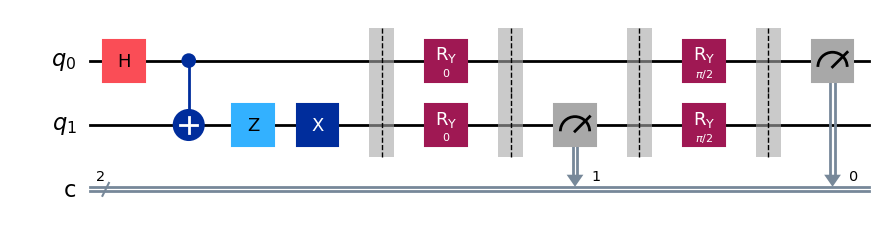

In [4]:
circAB = circ(thetaA,thetaB)
circAB.draw("mpl",scale=1)

**How to read the diagram:**

The diagram reads from left to right, with each solid horizontal black line representing a qubit. Alice's qubit is $q_1$ and Bob's qubit is $q_0$. Each box is an operator, or "gate", acting on the qubit. The black boxes with gauges on them measure the qubit and outputs the result to the classical readout bits (double lines at the bottom). 

The vertical lines crossing the qubits are "barriers" that do not affect the qubits and are introduced to highlight different parts of the operations in the diagram. 

The first part of the circuit up to the first "barrier" initializes the two qubits in the single state. We showed in a previous Qiskit exercise that the first two gates ("H" and "CNOT") create the superposition $\left(|00\rangle + |11\rangle\right)/\sqrt{2}$. The Z gate on $q_1$ introduces a minus sign in the second term, $\left(|00\rangle - |11\rangle\right)/\sqrt{2}$, and the X gate on $q_1$ swaps the entries to create the required state $|\psi\rangle$.

The following parts account for the rotations of the state first into the direction ${\bf a}$ followed by the measurement of Alice and then rotation into the direction ${\bf b}$ followed by the measurement of Bob.

**How to determine expected spin correlations:**

It's now time to make some actual measurements. The quantity $C({\bf a}, {\bf b})$ was defined as the average product of spin orientations measured by Alice along axis ${\bf a}$ and Bob along axis ${\bf b}$. For instance, if Alice measures "+" and Bob measures "-" the outcome would correspond to the correlation $(+1)(-1) = -1$. After the measurement the state would be $|01\rangle$ in the notation of quantum circuits, i.e. $q_0=1$ (corresponding to Bob's state $|-\rangle$) and $q_1=0$ (corresponding to Alice's state $|+\rangle$).

Of course, the result "Alice: + / Bob: -" is only one out of four possible outcomes. The other three are "Alice: + / Bob: +", "Alice: - / Bob: +" and "Alice: - / Bob: -". The code below allows us to simulate the quantum circuit repeatedly and to determine the distribution of these outcomes.

In [5]:
def get_result_from_simulation(circ, Nmeasure = 10000) :
    
    """Repeated simulation and measurement of Quantum Circuit"""
    
    # The parameter Nmeasure gives the number of repeated measurements you want to run 
    # and is preset Nmeasure = 10000. You can increase this if you like, but keep in 
    # mind that this will take more time.

    # quantum computer simulator (including a simulator of noise)        
    backend = FakeManilaV2()
    print("Running on IBM simulator: ",backend.name)
        
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circ)
 
    sampler = Sampler(mode=backend)
    result = sampler.run([isa_circuit],shots=Nmeasure).result()

    return result

def result_to_quasi_prob(result):

    """Convert result to quasi-probabilites"""
    
    # the counts of different qubit combinations after Nmeasure repetitions:
    counts = result[0].data.c.get_counts()
    Nmeasure = sum(counts.values())

    # four possible outcomes of the qubit measurements:
    outcomes = ["11","10","01","00"]

    # their correspondence in terms of neutrino flavour combinations:
    measurements = {"11" : "Alice: - / Bob: -",\
                    "10" : "Alice: - / Bob: +",\
                    "01" : "Alice: + / Bob: -",\
                    "00" : "Alice: + / Bob: +"}
    
    # for convenience, let's convert the counts to quasi-probabilities:
    quasi_prob = dict()

    for outcome in outcomes :
        try:
            quasi_prob[measurements[outcome]] = counts[outcome]/Nmeasure
        except:
            quasi_prob[measurements[outcome]] = 0
    
    return quasi_prob

We now perform 10000 repeated measurements of Alice's and Bob's spins and summarizes the outcomes in form of the relative frequency of the four outcomes ("quasi-probabilities"). 

Running on IBM simulator:  fake_manila


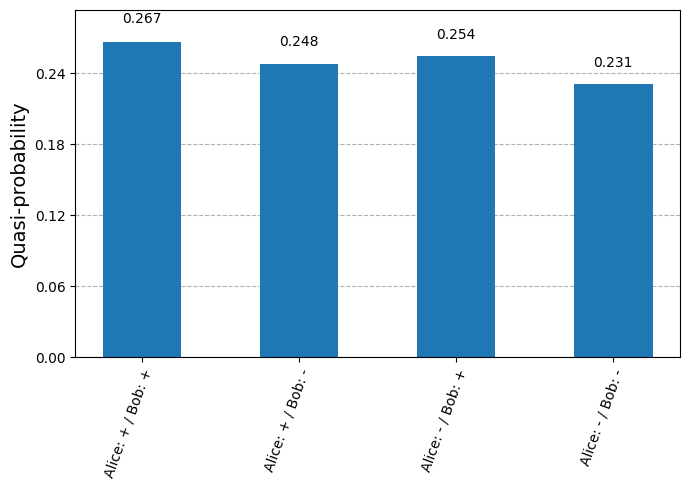

In [6]:
resultAB = get_result_from_simulation(circAB)
probabilitiesAB = result_to_quasi_prob(resultAB)
plot_distribution(probabilitiesAB)

The average spin correlation between measurements can now be determined using these quasi-probabilities as a weight. 

In [7]:
def quasi_prob_to_correlation(quasi_prob):

    """Convert quasi-probabilites to spin correlations"""
    
    return quasi_prob["Alice: - / Bob: -"]\
    + quasi_prob["Alice: + / Bob: +"]\
    - quasi_prob["Alice: - / Bob: +"]\
    - quasi_prob["Alice: + / Bob: -"]

The following code calculates the average correlation for the first measurement and stores the result as "Cab".

In [8]:
CabAB = quasi_prob_to_correlation(probabilitiesAB)

print("Expected spin correlation C(a,b) =",CabAB)

Expected spin correlation C(a,b) = -0.00500000000000006


To find a violation of Bell's inequality we have to repeat these measurements for two more orientations of the Stern-Gerlach measurement of Alice and Bob.

**B) Create two more quantum circuits for the measurement of $C({\bf b},{\bf c})$ and $C({\bf a},{\bf c})$. Create the histograms showing the probabilities of spin orientations for Alice and Bob and determine the observed spin correlations. Determine from these three measurements if Bell's inequality is violated or not.**

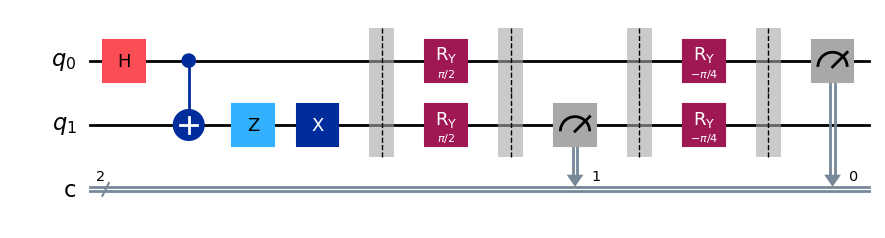

In [9]:
circBC = circ(thetaB,thetaC)
circBC.draw("mpl",scale=1)


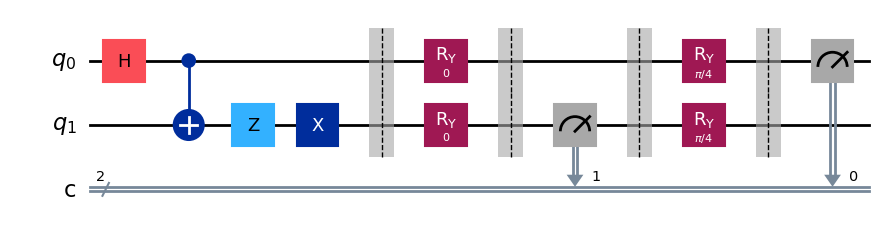

In [10]:
circAC = circ(thetaA,thetaC)
circAC.draw("mpl",scale=1)

Running on IBM simulator:  fake_manila


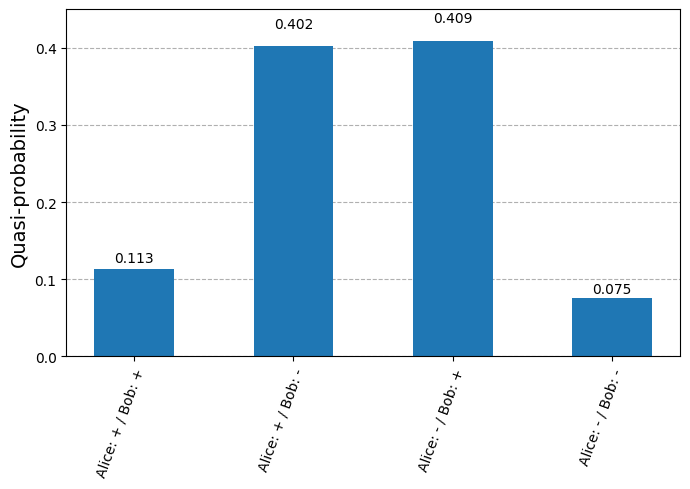

In [11]:
resultBC = get_result_from_simulation(circBC)
probabilitiesBC = result_to_quasi_prob(resultBC)
plot_distribution(probabilitiesBC)

In [12]:
CabBC = quasi_prob_to_correlation(probabilitiesBC)

print("Expected spin correlation C(b,c) =",CabBC)

Expected spin correlation C(b,c) = -0.6224


## We get C(b,c) = -0.6224 ##

Running on IBM simulator:  fake_manila


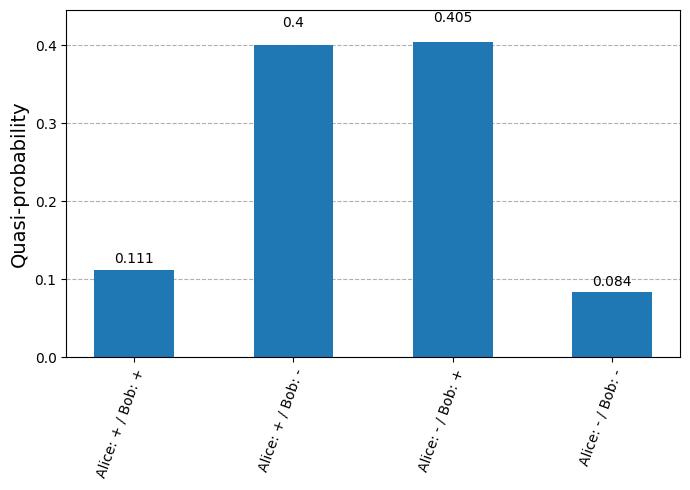

In [13]:
resultAC = get_result_from_simulation(circAC)
probabilitiesAC = result_to_quasi_prob(resultAC)
plot_distribution(probabilitiesAC)

In [14]:
CabAC = quasi_prob_to_correlation(probabilitiesAC)

print("Expected spin correlation C(a,c) =",CabAC)

Expected spin correlation C(a,c) = -0.609


## We get C(a,c) = -0.609 ##

In [15]:
print("Bell's Inequality ", CabAB - CabAC - CabBC, f"<= 1")
print("Expected Bell's Inequality from exercise 1.3)  ", np.sqrt(2), f"<= 1")

Bell's Inequality  1.2264 <= 1
Expected Bell's Inequality from exercise 1.3)   1.4142135623730951 <= 1


**Answear:** These calculations are pretty close to theory and probably just deviate due to erros, and **we determine that Bell's inequality is clearly violated** since 1.2264 is larger than 1. Concretely we get Bell's Inequality that says 1.2264 <= 1 where the expected  Bell's Inequality from exercise 1.3 said  1.4142135623730951 <= 1 The violation was not quite by $\sqrt2 -1 $ but pretty close.

**Comment:** It is also possible to run your circuits on actual quantum computers, not just simulators. For instance, IBM gives limited access to their Quantum Platform (https://quantum.cloud.ibm.com).